# 06. Análisis por distancia y por zona

En esta etapa no se modifica el método, sino que se intenta identificar **dónde** se concentran los fallos.

Para ello, el registro entre pares se separa según:
- distancia: `near`, `mid`, `far`,
- zona espacial: `front`, `left`, `right`.

Este análisis permite responder preguntas como:
- si el problema se concentra en larga distancia,
- si la región frontal registra mejor que los laterales,
- o si la combinación de todo el anillo introduce más ruido que beneficio.


In [1]:
from pathlib import Path
import json
import subprocess

import matplotlib.pyplot as plt


In [2]:
ROOT = Path('/home/clara/ml-depth-pro/slam_readiness_nuscenes')
RUN_SUMMARY = ROOT / 'outputs' / 'scene-0061' / 'run_summary.json'
SCRIPT_PATH = ROOT / 'scripts' / 'analyze_pairwise_regions.py'


## Función del script

Para cada pareja consecutiva, el script:
- filtra la pseudo-LiDAR según la región considerada,
- registra únicamente esa parte,
- y compara el movimiento estimado con el movimiento real.

Posteriormente, los resultados se promedian por región.


In [3]:
cmd = [
    'python',
    str(SCRIPT_PATH),
    '--run-summary', str(RUN_SUMMARY),
    '--dataroot', '/home/clara/datasets/nuscenes',
    '--version', 'v1.0-mini',
]
print(' '.join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)
print('returncode:', result.returncode)


python /home/clara/ml-depth-pro/slam_readiness_nuscenes/scripts/analyze_pairwise_regions.py --run-summary /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/run_summary.json --dataroot /home/clara/datasets/nuscenes --version v1.0-mini
/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/pairwise_region_analysis.json
{
  "all": {
    "translation_error_mean_m": 2.1787956239681563,
    "rotation_error_mean_deg": 3.594470517746576,
    "fitness_mean": 0.7991450457046032,
    "num_valid_pairs": 4
  },
  "near": {
    "translation_error_mean_m": 2.1621890421877215,
    "rotation_error_mean_deg": 5.410318448366885,
    "fitness_mean": 0.8626457127956901,
    "num_valid_pairs": 4
  },
  "mid": {
    "translation_error_mean_m": 3.2150047876491135,
    "rotation_error_mean_deg": 4.811100102720677,
    "fitness_mean": 0.7596652560536041,
    "num_valid_pairs": 4
  },
  "far": {
    "translation_error_mean_m": 3.652441043753942,
    "rotation_error_mean_deg": 1.474

In [4]:
analysis_path = ROOT / 'outputs' / 'scene-0061' / 'pairwise_region_analysis.json'
analysis = json.loads(analysis_path.read_text())
analysis['aggregate']


{'all': {'translation_error_mean_m': 2.1787956239681563,
  'rotation_error_mean_deg': 3.594470517746576,
  'fitness_mean': 0.7991450457046032,
  'num_valid_pairs': 4},
 'near': {'translation_error_mean_m': 2.1621890421877215,
  'rotation_error_mean_deg': 5.410318448366885,
  'fitness_mean': 0.8626457127956901,
  'num_valid_pairs': 4},
 'mid': {'translation_error_mean_m': 3.2150047876491135,
  'rotation_error_mean_deg': 4.811100102720677,
  'fitness_mean': 0.7596652560536041,
  'num_valid_pairs': 4},
 'far': {'translation_error_mean_m': 3.652441043753942,
  'rotation_error_mean_deg': 1.4740083659815388,
  'fitness_mean': 0.7356486794006535,
  'num_valid_pairs': 4},
 'front': {'translation_error_mean_m': 1.9059026777944292,
  'rotation_error_mean_deg': 2.3303987058296873,
  'fitness_mean': 0.7518827944175293,
  'num_valid_pairs': 4},
 'left': {'translation_error_mean_m': 2.0544675654617133,
  'rotation_error_mean_deg': 3.5634393646556033,
  'fitness_mean': 0.746707974622132,
  'num_valid

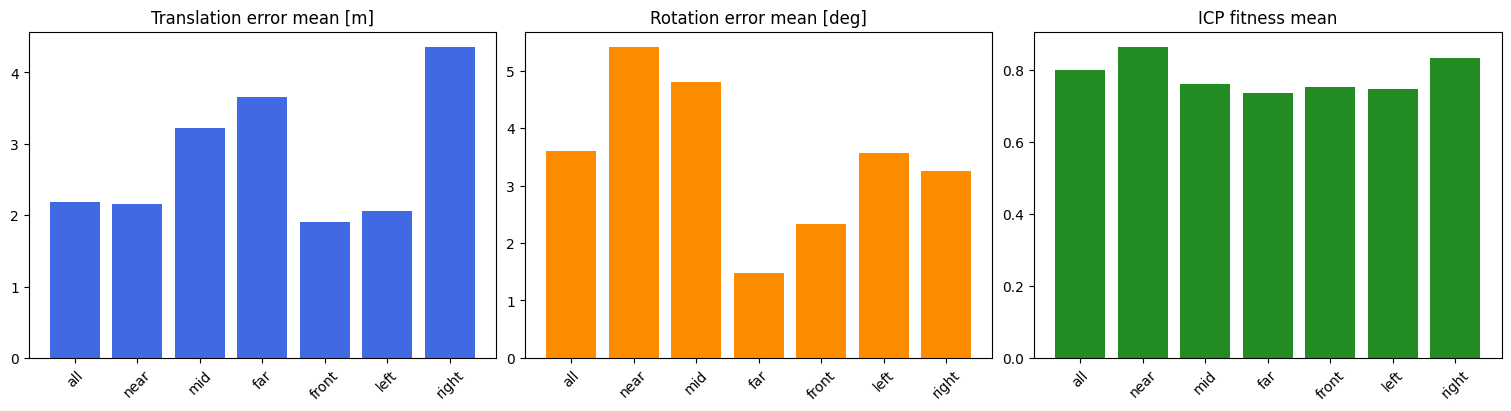

In [5]:
regions = ['all', 'near', 'mid', 'far', 'front', 'left', 'right']
trans_errors = [analysis['aggregate'][r]['translation_error_mean_m'] if analysis['aggregate'][r] else None for r in regions]
rot_errors = [analysis['aggregate'][r]['rotation_error_mean_deg'] if analysis['aggregate'][r] else None for r in regions]
fitness = [analysis['aggregate'][r]['fitness_mean'] if analysis['aggregate'][r] else None for r in regions]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].bar(regions, trans_errors, color='royalblue')
axes[0].set_title('Translation error mean [m]')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(regions, rot_errors, color='darkorange')
axes[1].set_title('Rotation error mean [deg]')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(regions, fitness, color='forestgreen')
axes[2].set_title('ICP fitness mean')
axes[2].tick_params(axis='x', rotation=45)

plt.show()


## Interpretación de este análisis

- Si `front` ofrece mejores resultados que `left/right`, podrá concluirse que el principal problema se concentra en los laterales.
- Si `near` mejora claramente a `far`, la larga distancia estará afectando de forma negativa al registro.
- Si `all` resulta peor que alguna subregión concreta, ello indicará que el uso del anillo completo puede estar introduciendo ruido adicional.

Este bloque permite justificar de manera más precisa en qué condiciones la pseudo-LiDAR puede resultar útil para tareas tipo SLAM.
